# Telco Churn EDA - Structured Notebook

Notebook này được tổ chức theo trình tự:
1. Setup và nạp dữ liệu
2. Data dictionary
3. Data quality check
4. Churn EDA (overview, categorical, numeric)
5. Feature importance baseline và gợi ý feature engineering

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [39]:
data = pd.read_csv(r"D:\giáo trình năm 3 kì 2\Data_mlops\WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) Data Dictionary

Bảng markdown thông tin dữ liệu:

| Tên cột | Mô tả |
|---|---|
| customerID | Customer ID |
| gender | Giới tính khách hàng (Male/Female) |
| SeniorCitizen | Khách hàng có phải người cao tuổi hay không (1, 0) |
| Partner | Khách hàng có bạn đời/đối tác hay không (Yes, No) |
| Dependents | Khách hàng có người phụ thuộc hay không (Yes, No) |
| tenure | Số tháng khách hàng đã gắn bó với công ty |
| PhoneService | Khách hàng có dịch vụ điện thoại hay không (Yes, No) |
| MultipleLines | Khách hàng có nhiều đường dây hay không (Yes, No, No phone service) |
| InternetService | Nhà cung cấp dịch vụ internet của khách hàng (DSL, Fiber optic, No) |
| OnlineSecurity | Khách hàng có bảo mật trực tuyến hay không (Yes, No, No internet service) |
| OnlineBackup | Khách hàng có sao lưu trực tuyến hay không (Yes, No, No internet service) |
| DeviceProtection | Khách hàng có bảo vệ thiết bị hay không (Yes, No, No internet service) |
| TechSupport | Khách hàng có hỗ trợ kỹ thuật hay không (Yes, No, No internet service) |
| StreamingTV | Khách hàng có dịch vụ xem TV trực tuyến hay không (Yes, No, No internet service) |
| StreamingMovies | Khách hàng có dịch vụ xem phim trực tuyến hay không (Yes, No, No internet service) |
| Contract | Loại hợp đồng của khách hàng (Month-to-month, One year, Two year) |
| PaperlessBilling | Khách hàng có dùng hóa đơn điện tử hay không (Yes, No) |
| PaymentMethod | Phương thức thanh toán (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)) |
| MonthlyCharges | Số tiền khách hàng bị tính mỗi tháng |
| TotalCharges | Tổng số tiền đã tính cho khách hàng |
| Churn | Khách hàng có rời bỏ dịch vụ hay không (Yes, No) |

## 2) Data Quality Check (Schema, Missing, Duplicates, Consistency)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [41]:
# Change datatype
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0)
data['SeniorCitizen'] = data['SeniorCitizen'].astype('bool')

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [44]:
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


In [45]:
data['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [46]:
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in cat_cols: cat_cols.remove('customerID')

print("\n--- KIỂM TRA SỰ NHẤT QUÁN CỦA CÁC GIÁ TRỊ ---")
for col in cat_cols:
    unique_vals = data[col].unique()
    # Kiểm tra xem nếu viết thường hết thì số lượng giá trị duy nhất có thay đổi không
    unique_lower = data[col].str.lower().str.strip().unique()
    
    print(f"{col}: {unique_vals}")
    if len(unique_vals) != len(unique_lower):
        print(f"  => CẢNH BÁO: Cột '{col}' cần chuẩn hóa (có sự khác biệt về viết hoa/thường hoặc khoảng trắng thừa).")


--- KIỂM TRA SỰ NHẤT QUÁN CỦA CÁC GIÁ TRỊ ---
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [47]:
# 1. Kiểm tra số lượng dòng trùng lặp hoàn toàn
duplicate_count = data.duplicated().sum()
print(f"Số lượng dòng trùng lặp hoàn toàn: {duplicate_count}")

# 2. Kiểm tra trùng lặp dựa trên mã khách hàng (customerID)
# Vì mỗi khách hàng chỉ nên xuất hiện một lần
id_duplicate_count = data['customerID'].duplicated().sum()
print(f"Số lượng customerID bị trùng: {id_duplicate_count}")

# 3. Hiển thị các dòng trùng lặp (nếu có) để kiểm tra
if duplicate_count > 0:
    print("\nCác dòng dữ liệu bị trùng:")
    display(data[data.duplicated(keep=False)].sort_values(by='customerID'))


Số lượng dòng trùng lặp hoàn toàn: 0
Số lượng customerID bị trùng: 0


In [48]:
# Encode các giá trị categorical thành số để dễ dàng phân tích
from sklearn.preprocessing import LabelEncoder
# Convert the column to float

data.drop(columns = ['customerID'], inplace = True)

le = LabelEncoder()

df1 = data.copy(deep = True)
text_data_features = [i for i in list(data.columns) if i not in list(data.describe().columns)]

print('Label Encoder Transformation')
for i in text_data_features :
    df1[i] = le.fit_transform(df1[i])
    print(i,' : ',df1[i].unique(),' = ',le.inverse_transform(df1[i].unique()))

Label Encoder Transformation
gender  :  [0 1]  =  ['Female' 'Male']
SeniorCitizen  :  [0 1]  =  [False  True]
Partner  :  [1 0]  =  ['Yes' 'No']
Dependents  :  [0 1]  =  ['No' 'Yes']
PhoneService  :  [0 1]  =  ['No' 'Yes']
MultipleLines  :  [1 0 2]  =  ['No phone service' 'No' 'Yes']
InternetService  :  [0 1 2]  =  ['DSL' 'Fiber optic' 'No']
OnlineSecurity  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
OnlineBackup  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
DeviceProtection  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
TechSupport  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingTV  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingMovies  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Contract  :  [0 1 2]  =  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling  :  [1 0]  =  ['Yes' 'No']
PaymentMethod  :  [2 3 0 1]  =  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn  :  [0 1]  =  ['No' 'Yes']

## 3) Churn EDA (Overview, Categorical, Numeric Distributions)

In [57]:
# 0) Chuẩn bị dữ liệu cho EDA Churn (chạy độc lập)
eda = pd.read_csv(r"D:\giáo trình năm 3 kì 2\Data_mlops\WA_Fn-UseC_-Telco-Customer-Churn.csv")
eda['TotalCharges'] = pd.to_numeric(eda['TotalCharges'], errors='coerce').fillna(0)
eda['SeniorCitizenLabel'] = eda['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
eda['ChurnFlag'] = (eda['Churn'] == 'Yes').astype(int)

print('Shape:', eda.shape)
print('\nTỷ lệ churn tổng thể (%):')
display((eda['Churn'].value_counts(normalize=True) * 100).rename('percent').round(2).to_frame())

Shape: (7043, 23)

Tỷ lệ churn tổng thể (%):


,percent
Churn,
No,73.46
Yes,26.54


In [58]:
# 1) Overview: so sánh các chỉ số numeric giữa Churn và Non-Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

overview_compare = (
    eda.groupby('Churn')[num_cols]
       .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
       .round(2)
)

print('So sánh thống kê numeric theo nhóm Churn')
display(overview_compare)

# Chênh lệch trung bình (Yes - No)
mean_diff = (
    eda.groupby('Churn')[num_cols]
       .mean()
       .loc['Yes']
       .sub(eda.groupby('Churn')[num_cols].mean().loc['No'])
       .rename('Mean_Yes_minus_No')
       .round(2)
       .to_frame()
)

print('Chênh lệch trung bình (Churn=Yes trừ Churn=No)')
display(mean_diff)

So sánh thống kê numeric theo nhóm Churn


tenure                            MonthlyCharges                     \
       count  mean median   std min max          count  mean median   std   
Churn                                                                       
No      5174 37.57  38.00 24.11   0  72           5174 61.27  64.43 31.09   
Yes     1869 17.98  10.00 19.53   1  72           1869 74.44  79.65 24.67   

                   TotalCharges                                        
        min    max        count    mean  median     std   min     max  
Churn                                                                  
No    18.25 118.75         5174 2549.91 1679.52 2329.95  0.00 8672.45  
Yes   18.85 118.35         1869 1531.80  703.55 1890.82 18.85 8684.80

Chênh lệch trung bình (Churn=Yes trừ Churn=No)


,Mean_Yes_minus_No
tenure,-19.59
MonthlyCharges,13.18
TotalCharges,-1018.12


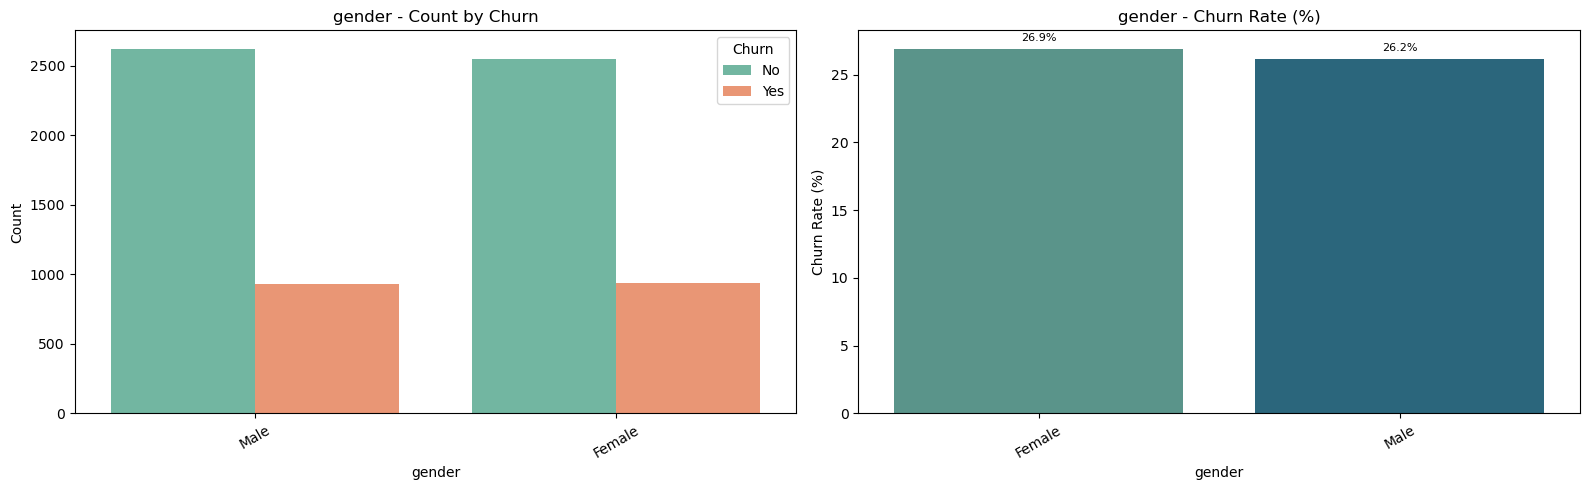

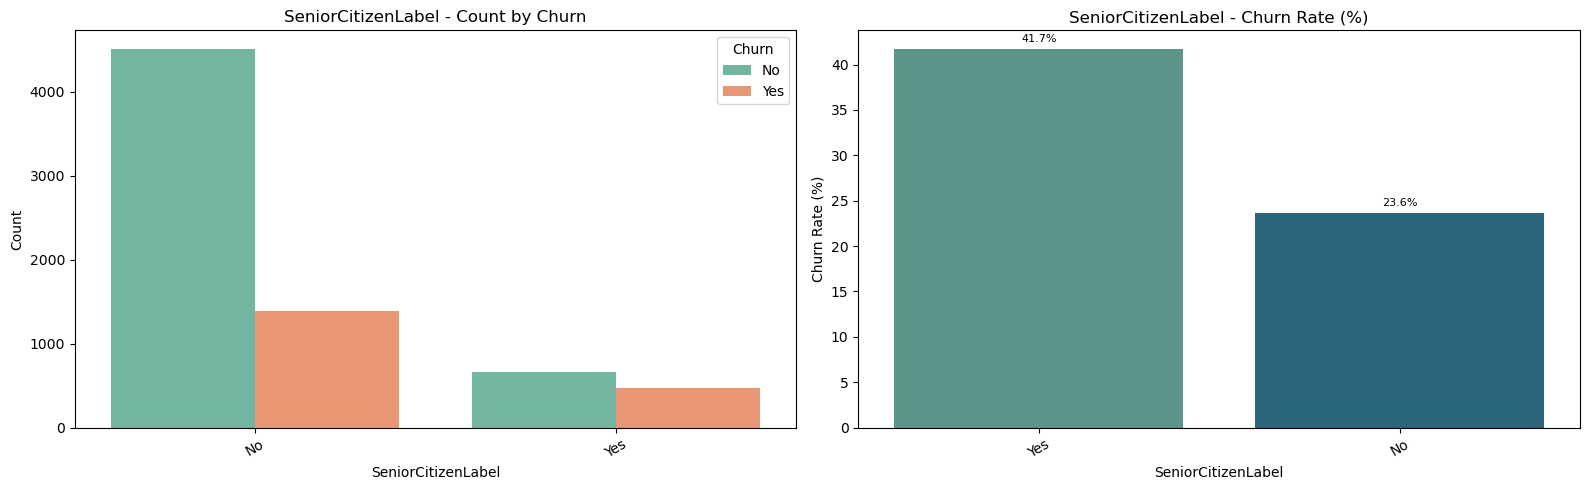

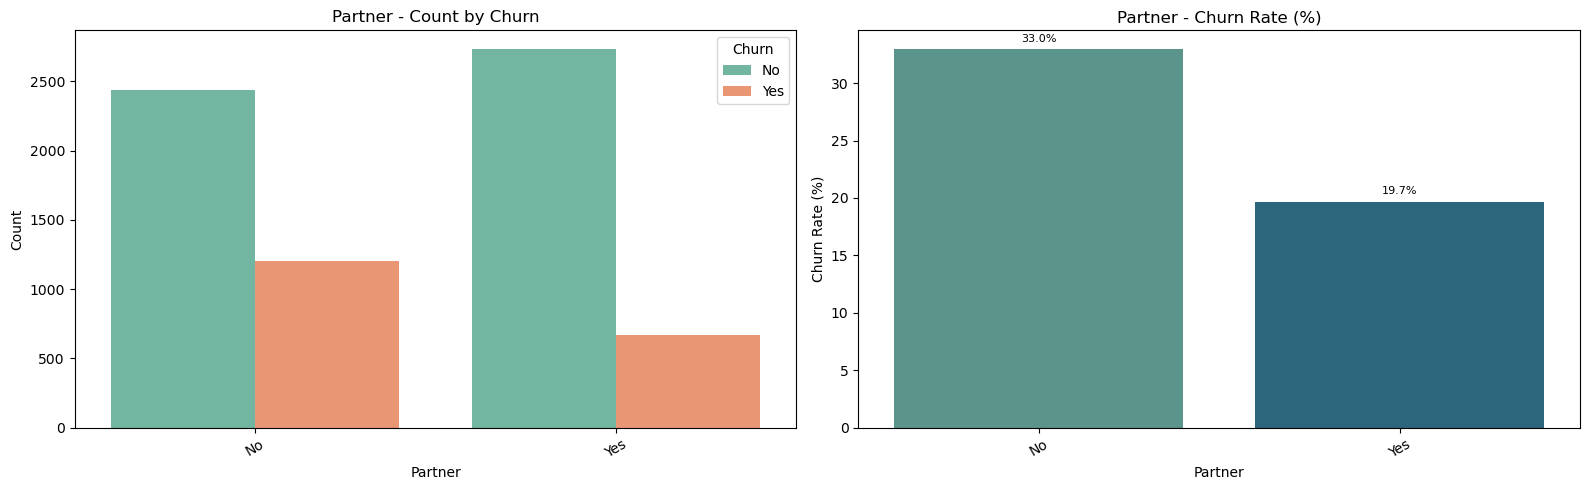

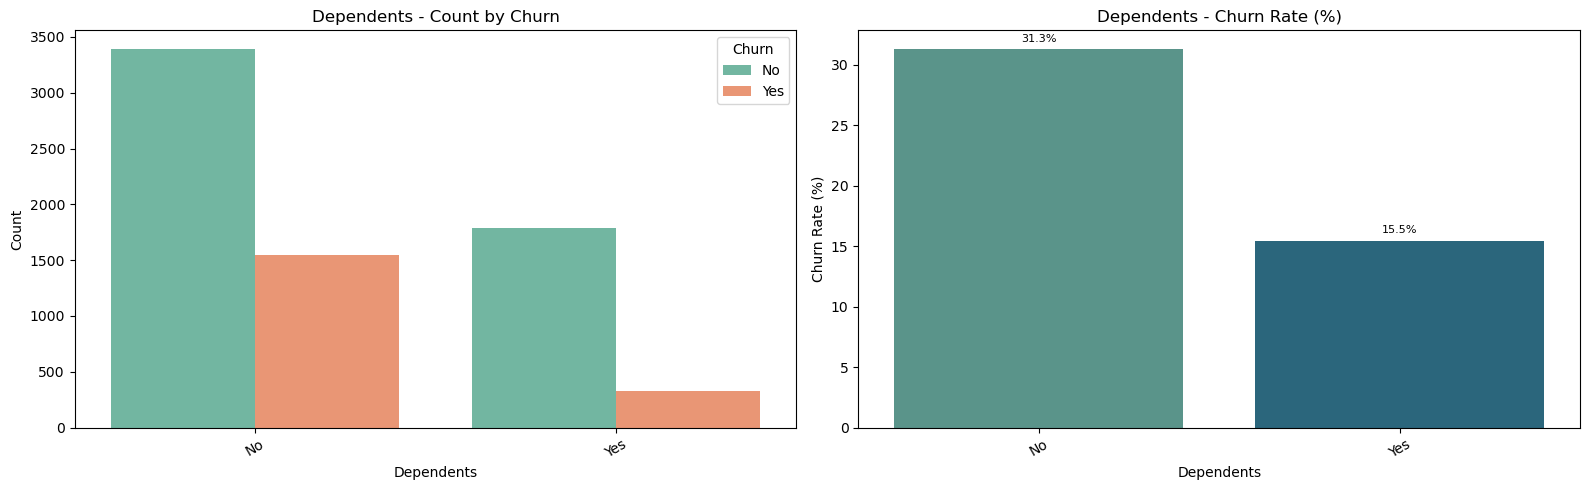

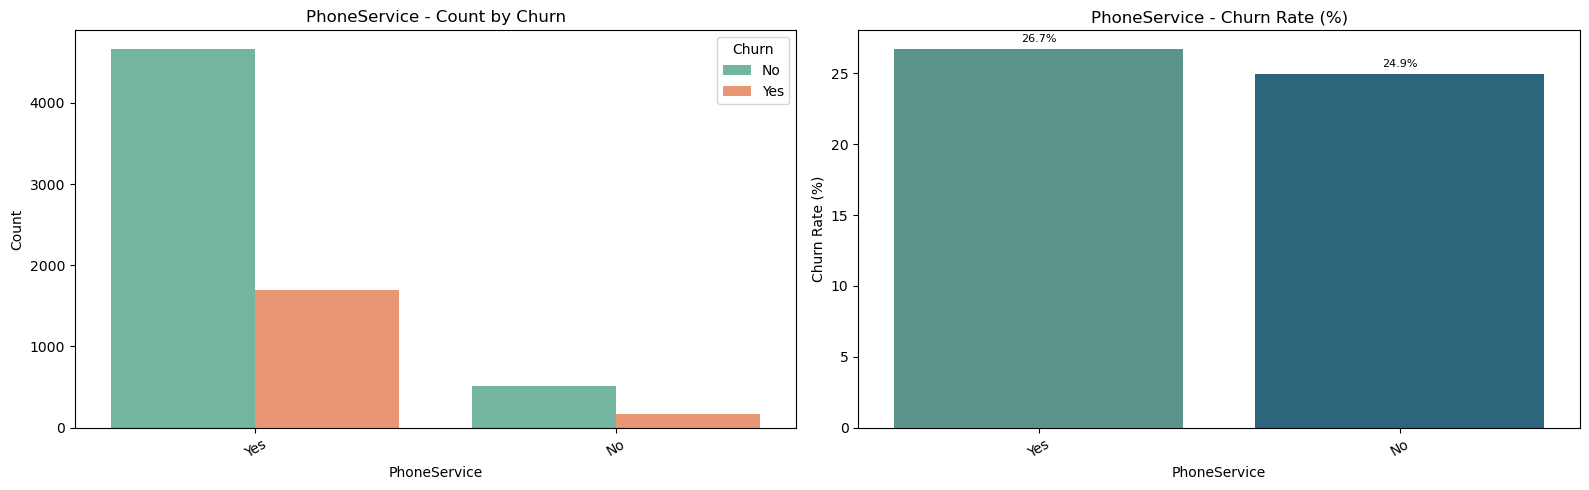

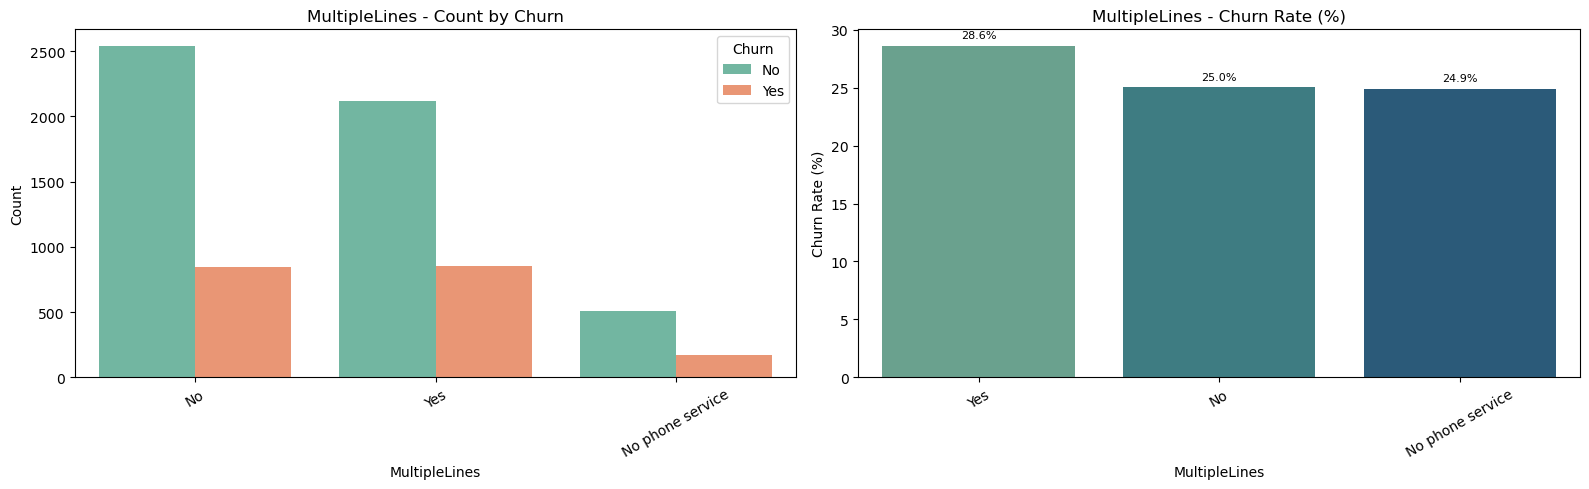

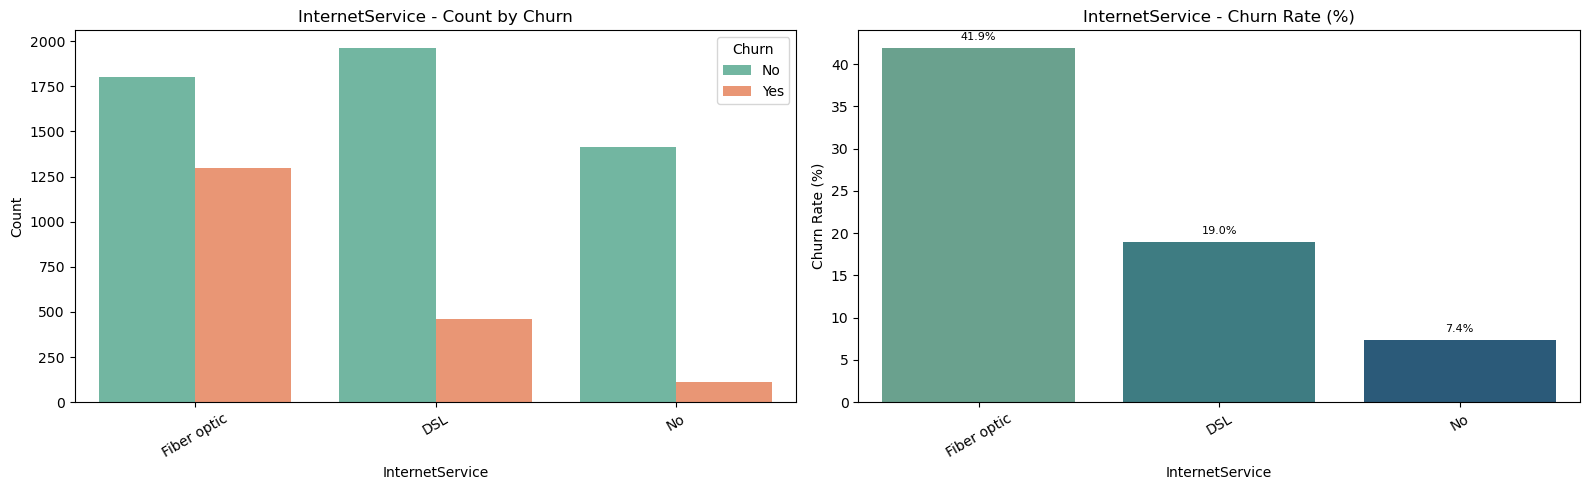

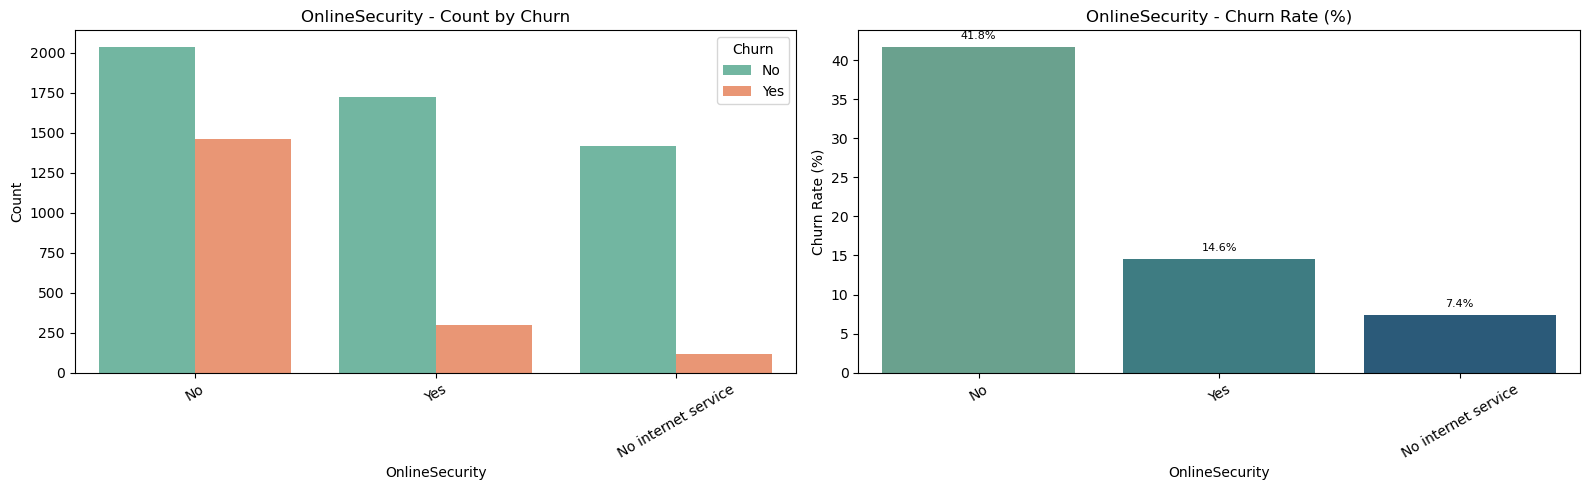

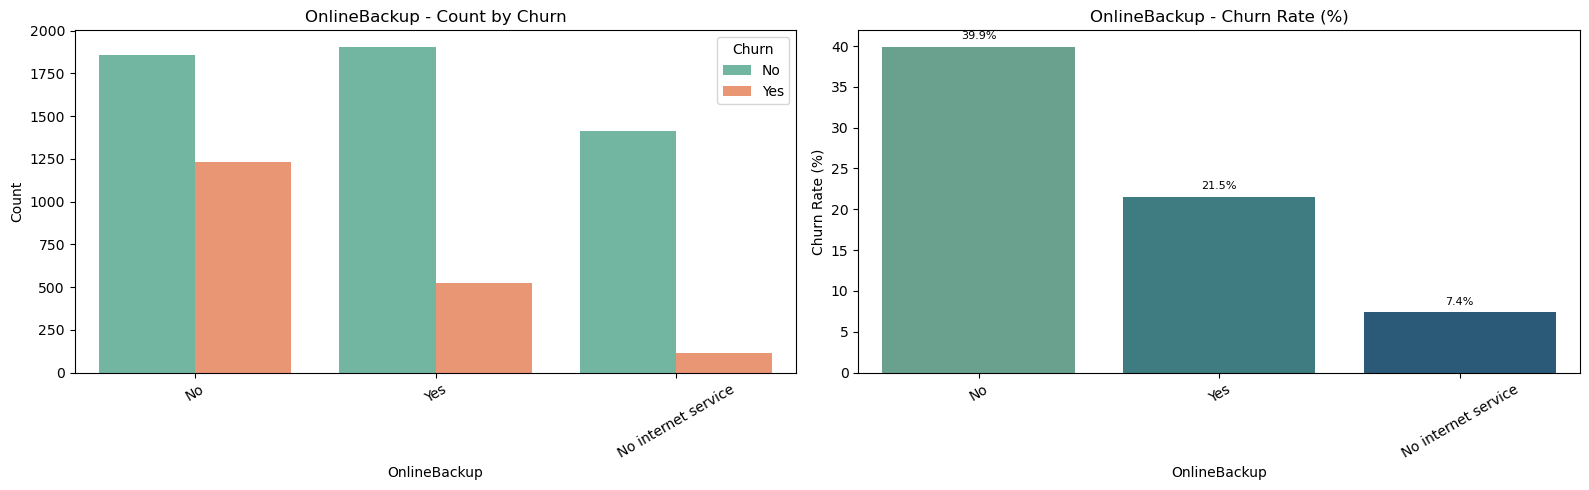

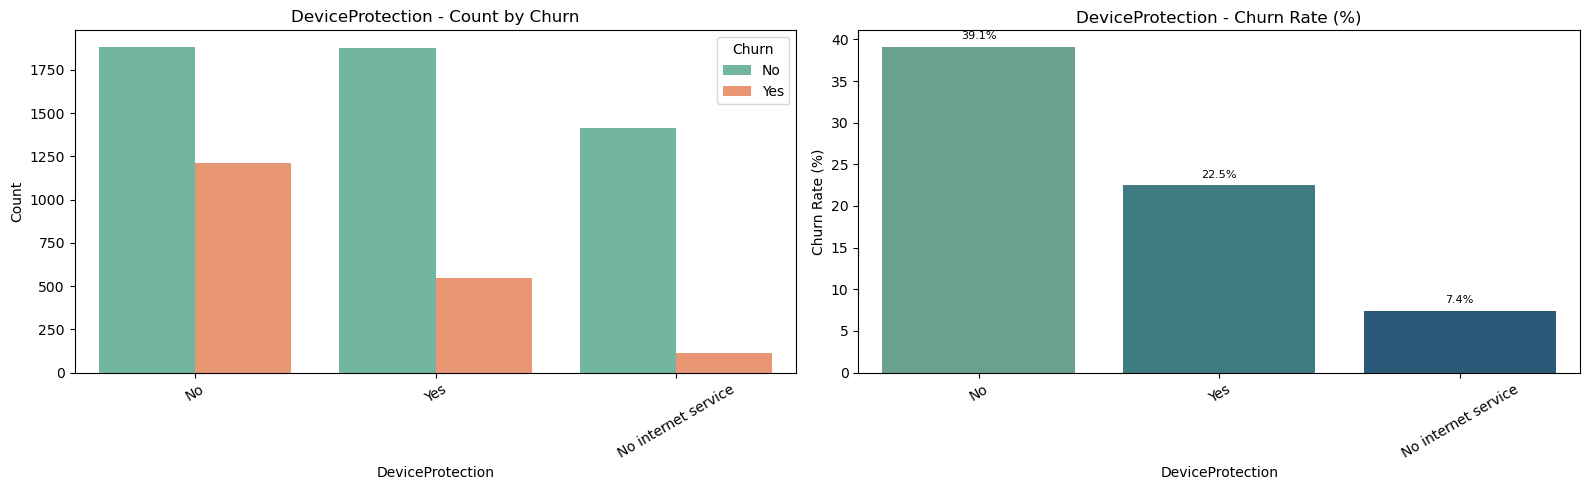

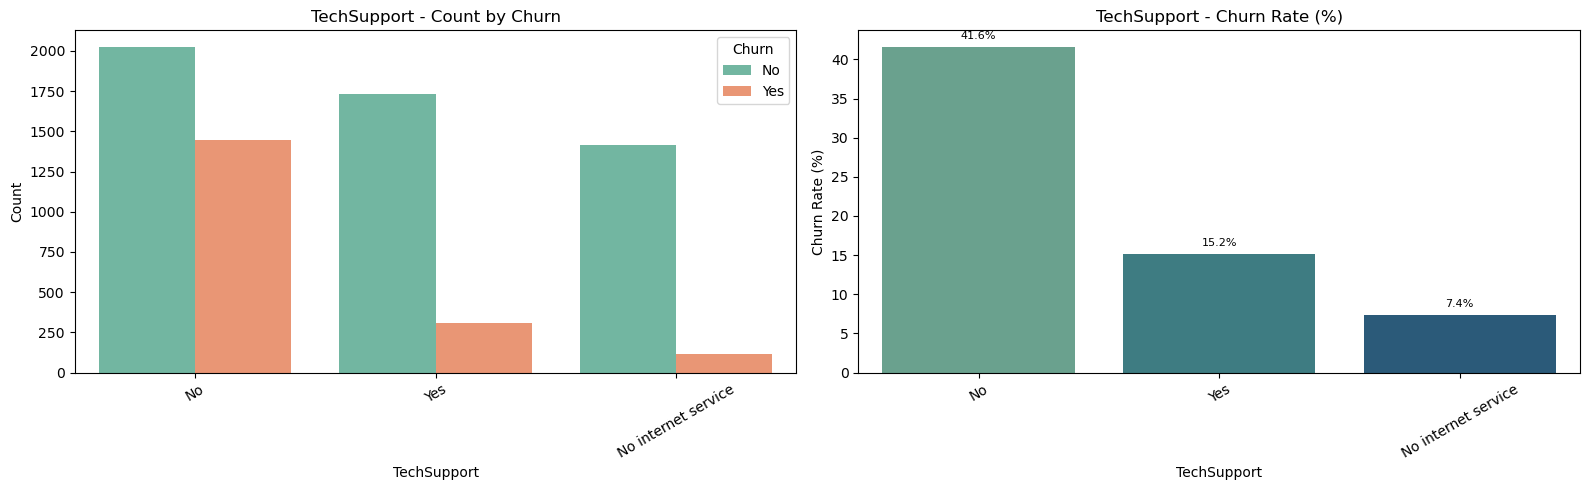

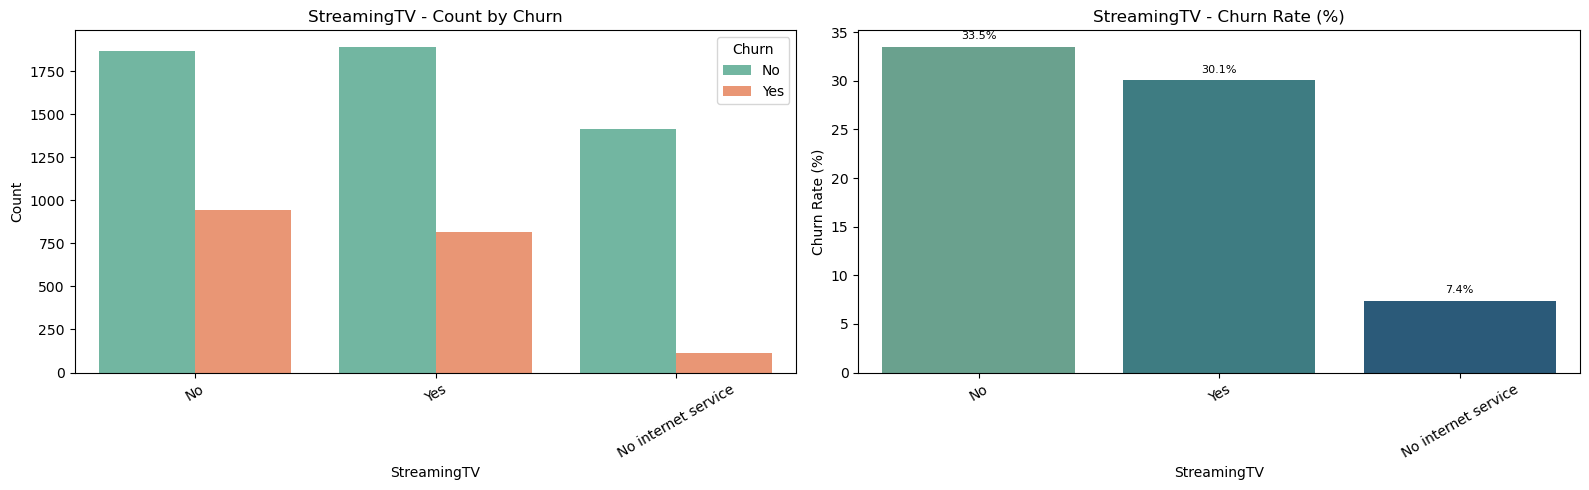

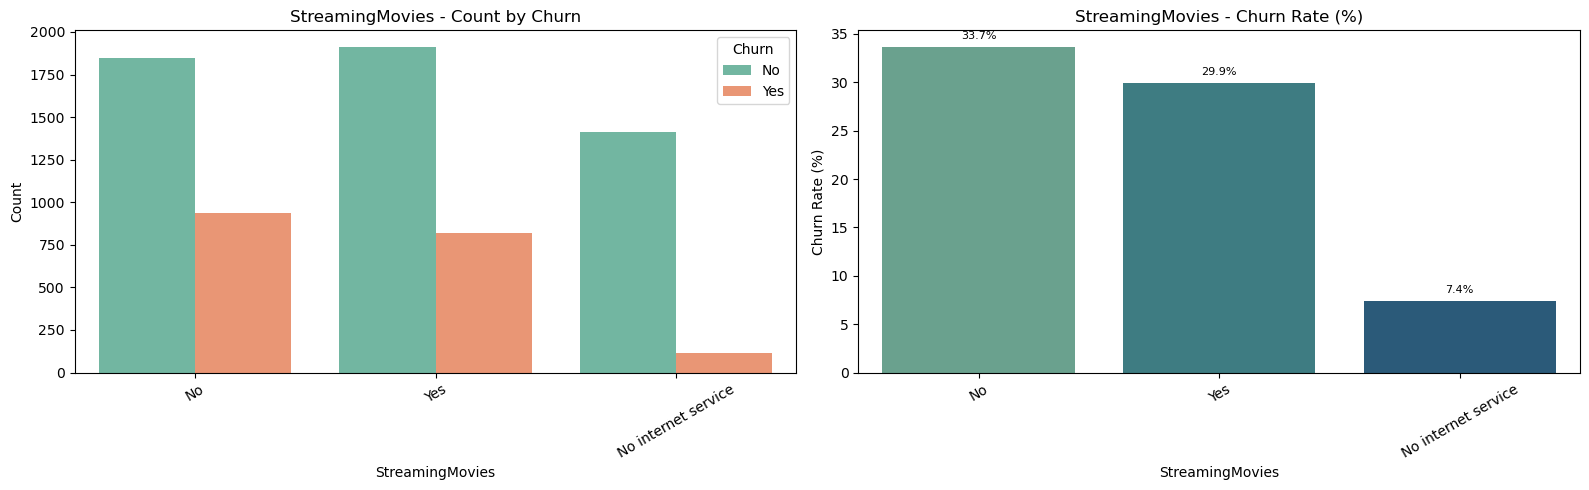

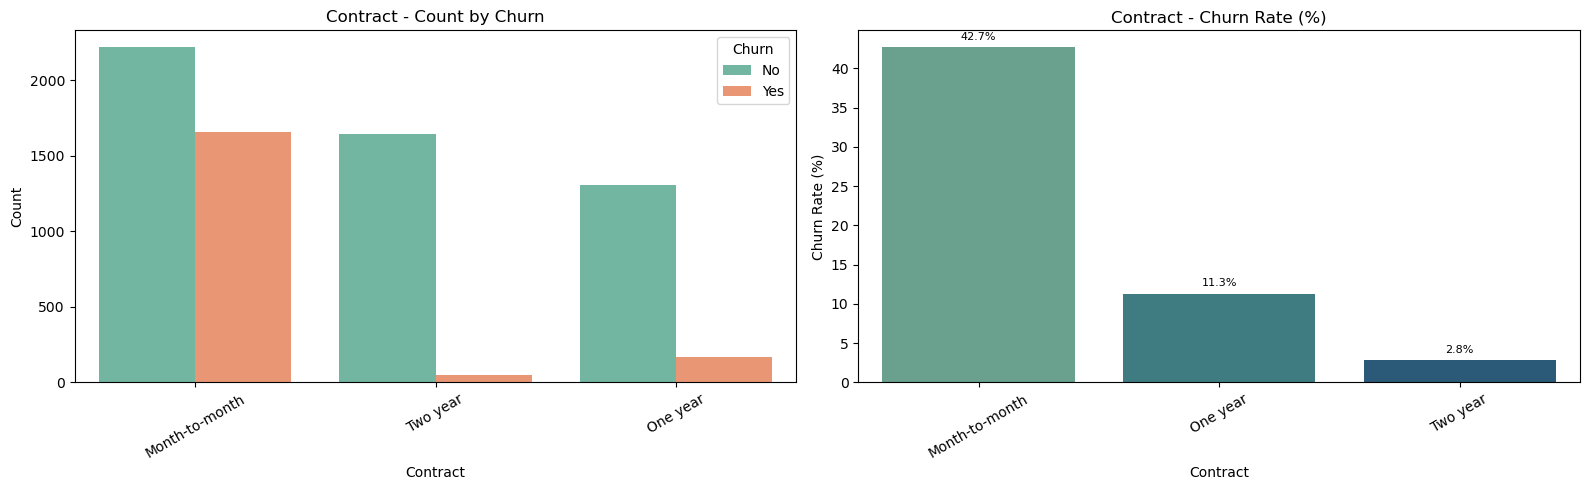

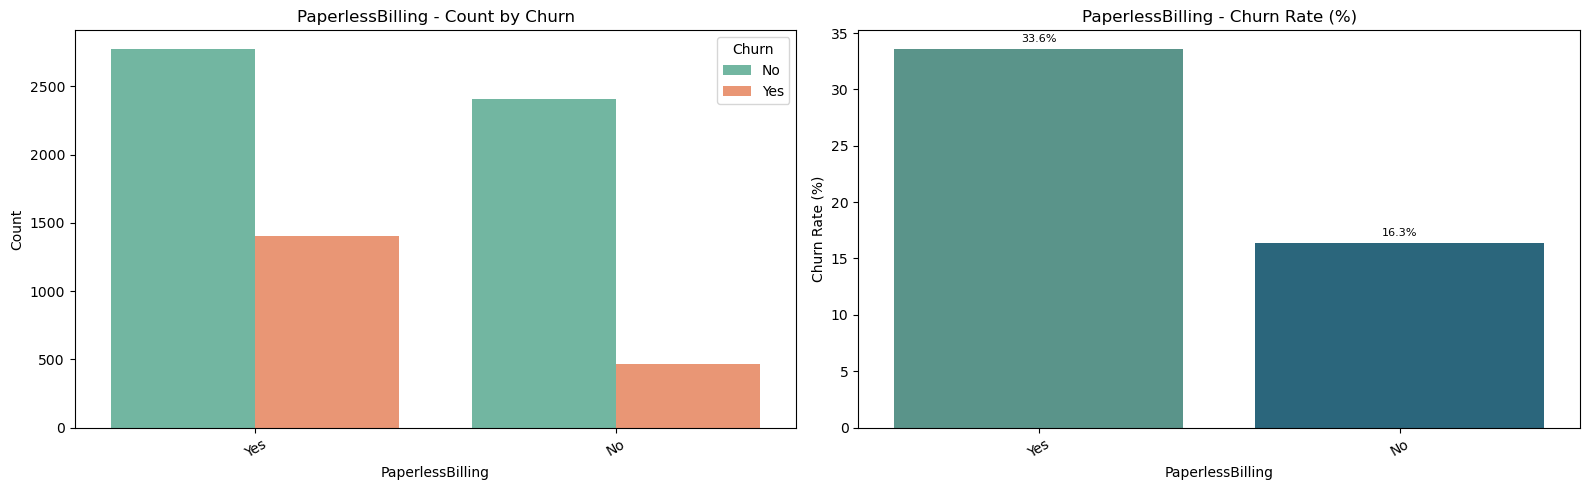

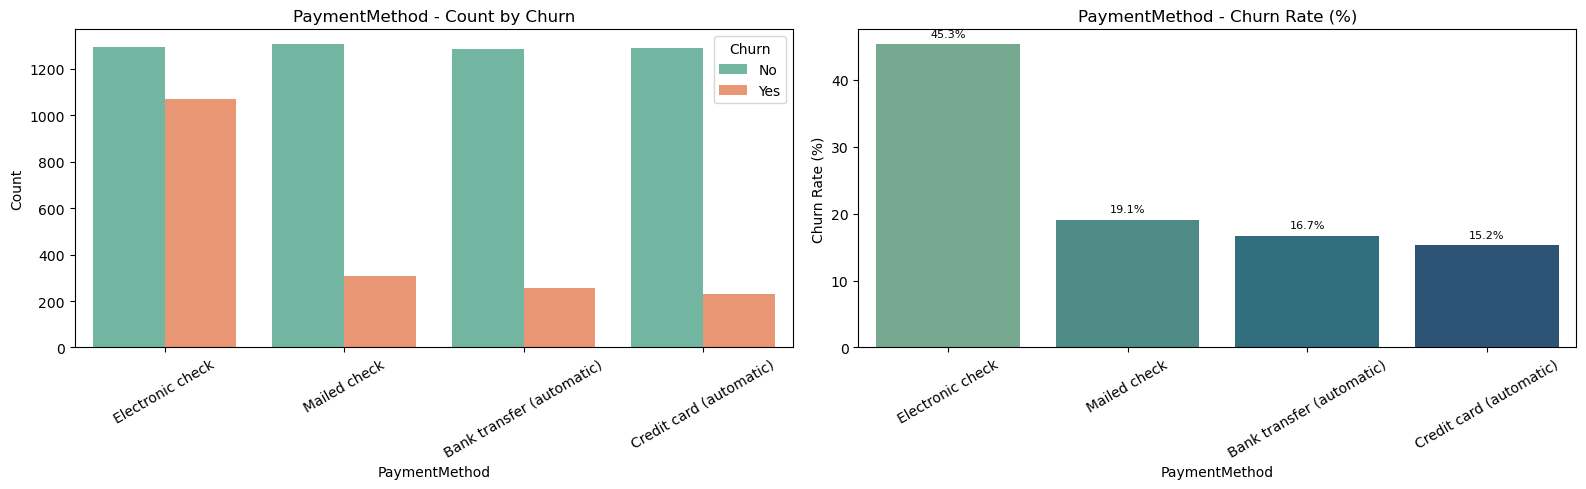

In [56]:
# 2) So sánh lần lượt từng biến categorical theo churn
cat_cols = [
    'gender', 'SeniorCitizenLabel', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Biểu đồ số lượng theo churn
    order_count = eda[col].value_counts().index
    sns.countplot(data=eda, x=col, hue='Churn', order=order_count, ax=axes[0], palette='Set2')
    axes[0].set_title(f'{col} - Count by Churn')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Churn')

    # Biểu đồ tỷ lệ churn theo từng category
    churn_rate = (
        eda.groupby(col)['ChurnFlag']
           .mean()
           .sort_values(ascending=False)
           .mul(100)
           .reset_index(name='churn_rate_pct')
    )
    sns.barplot(data=churn_rate, x=col, y='churn_rate_pct', ax=axes[1], palette='crest')
    axes[1].set_title(f'{col} - Churn Rate (%)')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)

    for p in axes[1].patches:
        height = p.get_height()
        axes[1].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2, height),
                         ha='center', va='bottom', fontsize=8, xytext=(0, 4),
                         textcoords='offset points')

    plt.tight_layout()
    plt.show()

In [52]:
# 3) Bảng tổng hợp churn rate theo từng category để đọc nhanh insight
cat_summary_frames = []

for col in cat_cols:
    tmp = (
        eda.groupby(col)['ChurnFlag']
           .agg(n='count', churn_rate='mean')
           .reset_index()
    )
    tmp['feature'] = col
    tmp['value'] = tmp[col].astype(str)
    tmp['churn_rate_pct'] = (tmp['churn_rate'] * 100).round(2)
    cat_summary_frames.append(tmp[['feature', 'value', 'n', 'churn_rate_pct']])

cat_summary = pd.concat(cat_summary_frames, ignore_index=True)

feature_gap = (
    cat_summary.groupby('feature')['churn_rate_pct']
               .agg(['min', 'max'])
               .assign(gap=lambda x: (x['max'] - x['min']).round(2))
               .sort_values('gap', ascending=False)
)

print('Top nhóm có churn rate cao nhất')
display(cat_summary.sort_values('churn_rate_pct', ascending=False).head(15))

print('Top nhóm có churn rate thấp nhất')
display(cat_summary.sort_values('churn_rate_pct', ascending=True).head(15))

print('Độ phân tách churn theo từng feature (max-min churn rate)')
display(feature_gap.head(10))

Top nhóm có churn rate cao nhất


,feature,value,n,churn_rate_pct
41,PaymentMethod,Electronic check,2365,45.29
34,Contract,Month-to-month,3875,42.71
14,InternetService,Fiber optic,3096,41.89
16,OnlineSecurity,No,3498,41.77
3,SeniorCitizenLabel,Yes,1142,41.68
25,TechSupport,No,3473,41.64
19,OnlineBackup,No,3088,39.93
22,DeviceProtection,No,3095,39.13
31,StreamingMovies,No,2785,33.68
38,PaperlessBilling,Yes,4171,33.57


Top nhóm có churn rate thấp nhất


,feature,value,n,churn_rate_pct
36,Contract,Two year,1695,2.83
15,InternetService,No,1526,7.40
20,OnlineBackup,No internet service,1526,7.40
23,DeviceProtection,No internet service,1526,7.40
26,TechSupport,No internet service,1526,7.40
17,OnlineSecurity,No internet service,1526,7.40
32,StreamingMovies,No internet service,1526,7.40
29,StreamingTV,No internet service,1526,7.40
35,Contract,One year,1473,11.27
18,OnlineSecurity,Yes,2019,14.61


Độ phân tách churn theo từng feature (max-min churn rate)


,min,max,gap
feature,,,
Contract,2.83,42.71,39.88
InternetService,7.40,41.89,34.49
OnlineSecurity,7.40,41.77,34.37
TechSupport,7.40,41.64,34.24
OnlineBackup,7.40,39.93,32.53
DeviceProtection,7.40,39.13,31.73
PaymentMethod,15.24,45.29,30.05
StreamingMovies,7.40,33.68,26.28
StreamingTV,7.40,33.52,26.12


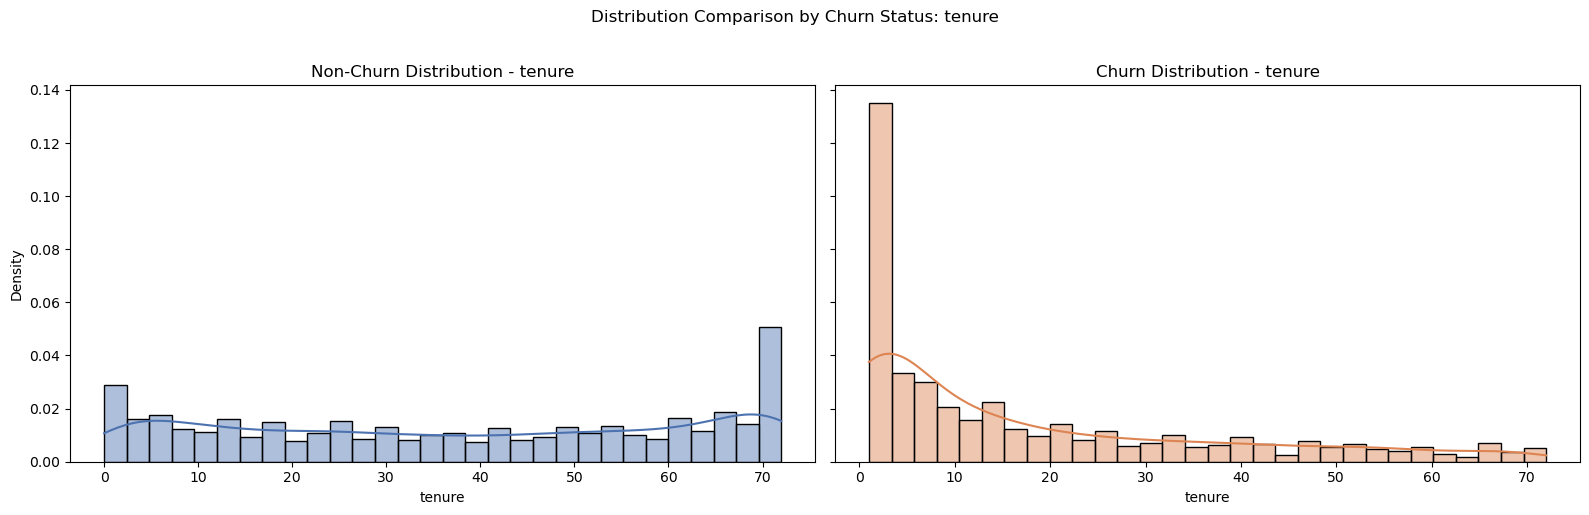

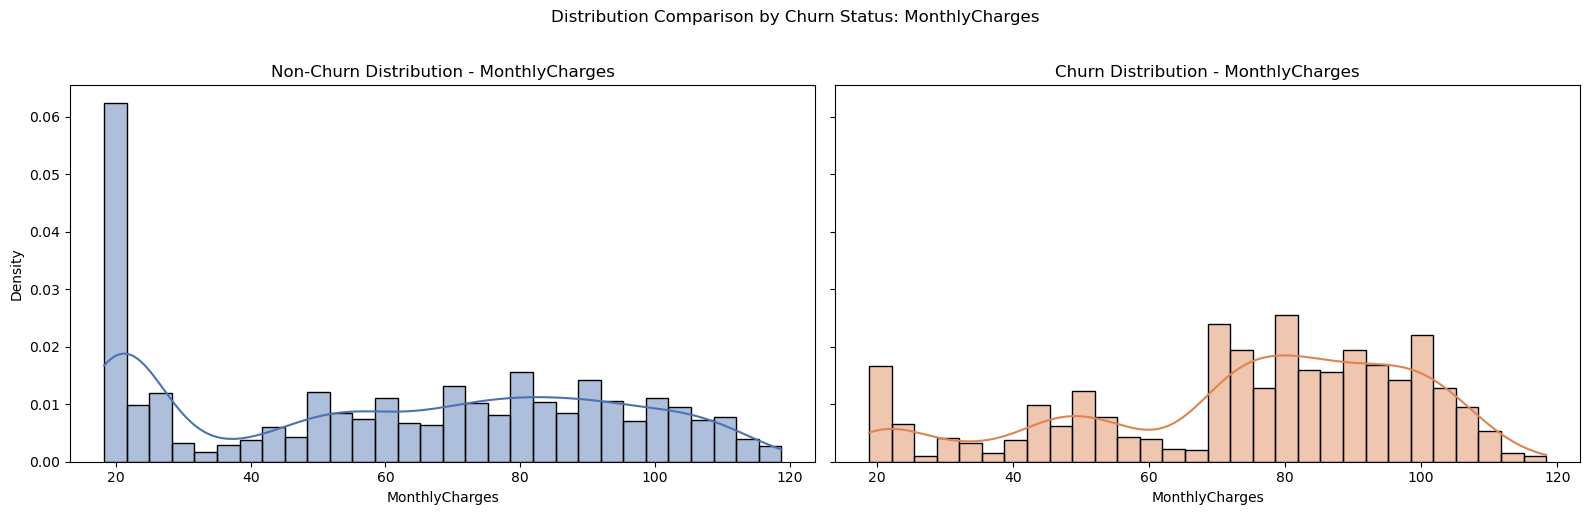

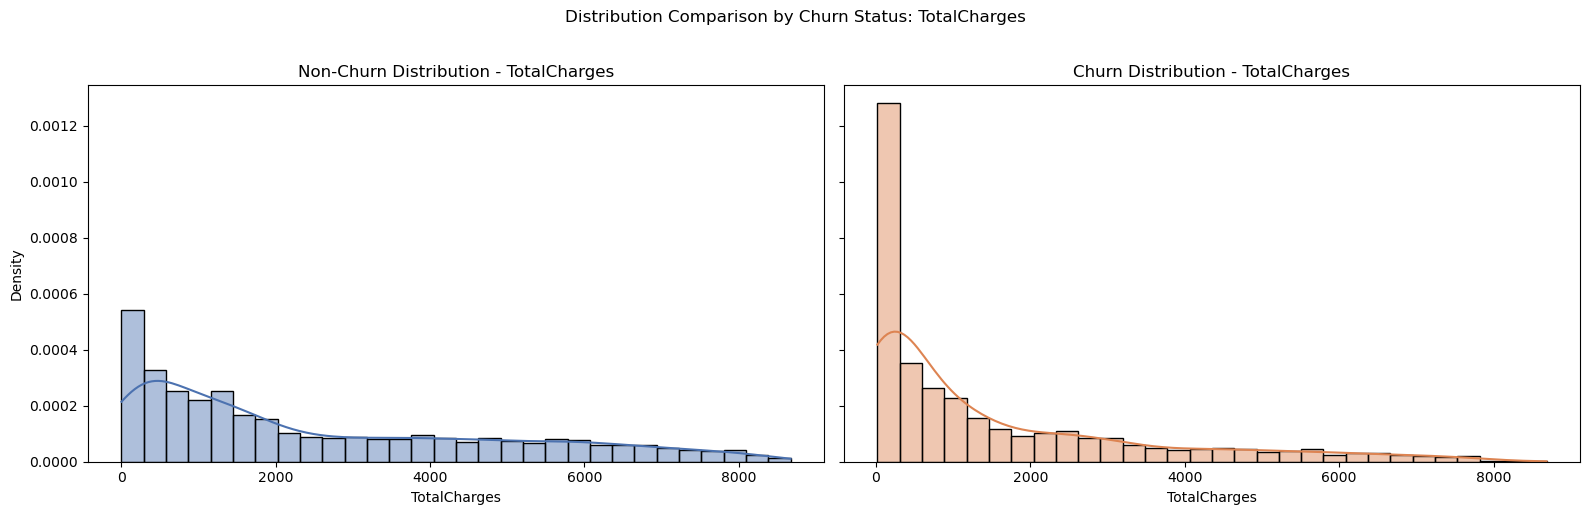

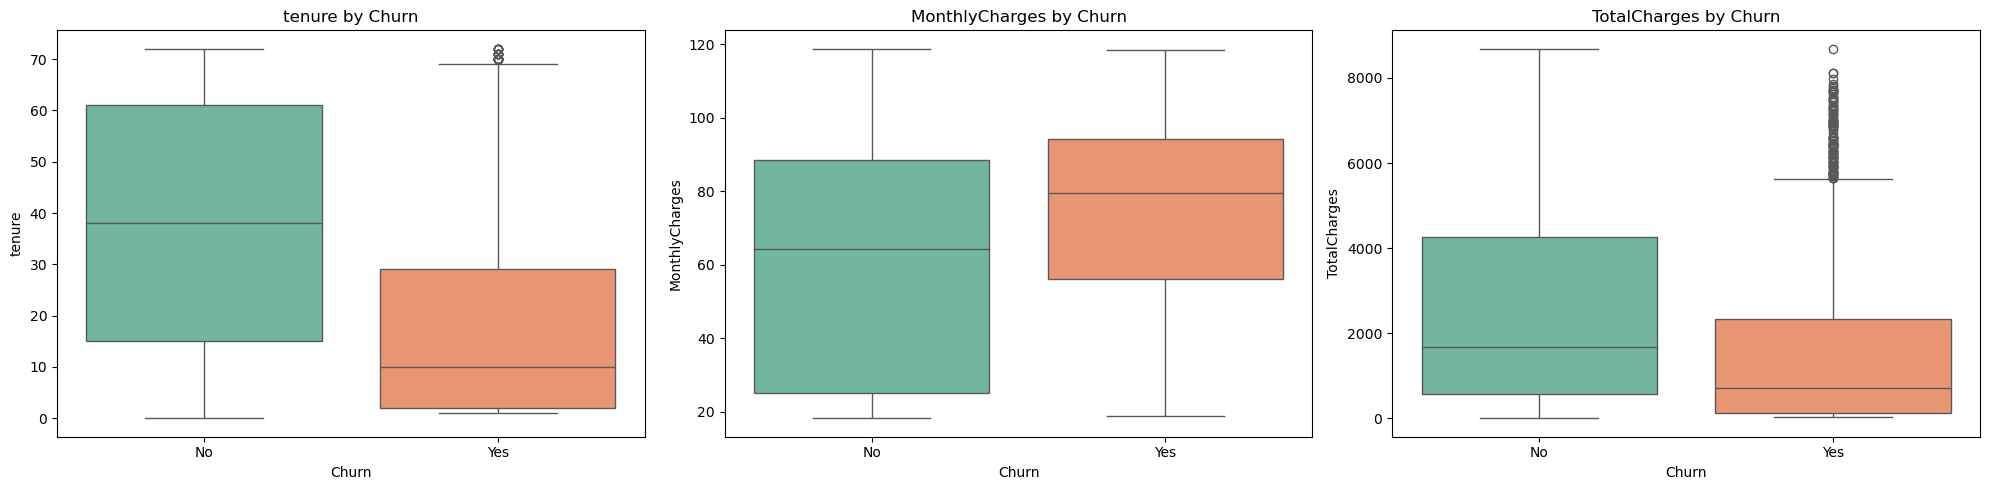

In [59]:
# 4) Distribution numeric tách riêng 2 nhóm: Non-Churn và Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    sns.histplot(
        data=eda[eda['Churn'] == 'No'],
        x=col,
        bins=30,
        kde=True,
        stat='density',
        color='#4C72B0',
        alpha=0.45,
        ax=axes[0]
    )
    axes[0].set_title(f'Non-Churn Distribution - {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Density')

    sns.histplot(
        data=eda[eda['Churn'] == 'Yes'],
        x=col,
        bins=30,
        kde=True,
        stat='density',
        color='#DD8452',
        alpha=0.45,
        ax=axes[1]
    )
    axes[1].set_title(f'Churn Distribution - {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Density')

    plt.suptitle(f'Distribution Comparison by Churn Status: {col}', y=1.02)
    plt.tight_layout()
    plt.show()

# Boxplot để thấy median/IQR rõ hơn
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=eda, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()

## 6) Nhận xét tổng hợp từ EDA

### 1) Tổng quan churn
- Tỷ lệ churn tổng thể khoảng **26.54%**, non-churn khoảng **73.46%**. Dữ liệu bị lệch lớp mức vừa.

### 2) So sánh numeric giữa churn và non-churn
- Nhóm **churn có tenure thấp hơn rõ rệt** (trung bình khoảng 17.98 tháng) so với non-churn (khoảng 37.57 tháng).
- Nhóm **churn có MonthlyCharges cao hơn** (trung bình khoảng 74.44) so với non-churn (khoảng 61.27).
- `TotalCharges` của nhóm churn thấp hơn do thời gian gắn bó ngắn hơn, không có nghĩa là mức trả theo tháng thấp.

### 3) So sánh theo từng categorical
- Các biến có độ phân tách churn mạnh nhất (gap churn rate lớn): **Contract, InternetService, OnlineSecurity, TechSupport, PaymentMethod**.
- Nhóm rủi ro cao thường gặp: `Contract = Month-to-month`, `PaymentMethod = Electronic check`, `InternetService = Fiber optic`, thiếu `OnlineSecurity` hoặc `TechSupport`.
- Nhóm rủi ro thấp hơn rõ rệt: `Contract = Two year`, `InternetService = No`, có `OnlineSecurity` và `TechSupport`.

### 4) Nhìn từ distribution/boxplot
- `tenure`: phân phối churn lệch về phía thấp (nhiều khách rời sớm).
- `MonthlyCharges`: churn tập trung nhiều hơn ở vùng phí hàng tháng cao.
- `TotalCharges`: nhóm non-churn có đuôi phải dài hơn do ở lại lâu hơn.

## 4) Feature Importance Baseline (Bước đệm cho Feature Engineering)

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Chuẩn bị dữ liệu baseline
X_base = eda.drop(columns=['Churn', 'ChurnFlag']).copy()
if 'customerID' in X_base.columns:
    X_base = X_base.drop(columns=['customerID'])

y = eda['ChurnFlag']

# One-hot encoding để train mô hình tree baseline
X_ohe = pd.get_dummies(X_base, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_ohe, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'Baseline RandomForest ROC-AUC: {auc:.4f}')

# Importance ở mức encoded feature
importance_encoded = pd.DataFrame({
    'encoded_feature': X_ohe.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Gộp importance về feature gốc để tiện định hướng feature engineering
original_cols = list(X_base.columns)

def map_to_original_feature(encoded_name, base_cols):
    for c in base_cols:
        if encoded_name == c or encoded_name.startswith(f'{c}_'):
            return c
    return encoded_name

importance_encoded['original_feature'] = importance_encoded['encoded_feature'].apply(
    lambda x: map_to_original_feature(x, original_cols)
)

importance_by_original = (
    importance_encoded.groupby('original_feature', as_index=False)['importance']
                     .sum()
                     .sort_values('importance', ascending=False)
)

print('\nTop encoded features (chi tiết):')
display(importance_encoded.head(20))

print('Top original features (gộp theo cột gốc):')
display(importance_by_original.head(15))

Baseline RandomForest ROC-AUC: 0.8378

Top encoded features (chi tiết):


,encoded_feature,importance,original_feature
1,tenure,0.13,tenure
3,TotalCharges,0.12,TotalCharges
2,MonthlyCharges,0.10,MonthlyCharges
36,Contract_Month-to-month,0.09,Contract
18,OnlineSecurity_No,0.05,OnlineSecurity
38,Contract_Two year,0.04,Contract
27,TechSupport_No,0.04,TechSupport
16,InternetService_Fiber optic,0.03,InternetService
43,PaymentMethod_Electronic check,0.03,PaymentMethod
21,OnlineBackup_No,0.02,OnlineBackup


Top original features (gộp theo cột gốc):


,original_feature,importance
0,Contract,0.15
19,tenure,0.13
17,TotalCharges,0.12
4,MonthlyCharges,0.10
7,OnlineSecurity,0.06
10,PaymentMethod,0.06
16,TechSupport,0.06
3,InternetService,0.05
6,OnlineBackup,0.04
2,DeviceProtection,0.03


In [61]:
# 5) Gợi ý feature engineering và quick check churn rate
fe = eda.copy()

# Các feature gợi ý dựa trên insight EDA
fe['is_monthly_contract'] = (fe['Contract'] == 'Month-to-month').astype(int)
fe['is_electronic_check'] = (fe['PaymentMethod'] == 'Electronic check').astype(int)
fe['has_security'] = (fe['OnlineSecurity'] == 'Yes').astype(int)
fe['has_techsupport'] = (fe['TechSupport'] == 'Yes').astype(int)
fe['high_monthly_charge'] = (fe['MonthlyCharges'] >= fe['MonthlyCharges'].quantile(0.75)).astype(int)

fe['tenure_group'] = pd.cut(
    fe['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)

fe['service_yes_count'] = (
    (fe['PhoneService'] == 'Yes').astype(int)
    + (fe['MultipleLines'] == 'Yes').astype(int)
    + (fe['OnlineSecurity'] == 'Yes').astype(int)
    + (fe['OnlineBackup'] == 'Yes').astype(int)
    + (fe['DeviceProtection'] == 'Yes').astype(int)
    + (fe['TechSupport'] == 'Yes').astype(int)
    + (fe['StreamingTV'] == 'Yes').astype(int)
    + (fe['StreamingMovies'] == 'Yes').astype(int)
)

fe_checks = [
    'is_monthly_contract',
    'is_electronic_check',
    'has_security',
    'has_techsupport',
    'high_monthly_charge',
    'tenure_group'
]

for c in fe_checks:
    print(f'\nChurn rate theo {c}:')
    display((fe.groupby(c)['ChurnFlag'].mean() * 100).round(2).to_frame('churn_rate_pct'))

print('\nTương quan service_yes_count với ChurnFlag:')
print(fe[['service_yes_count', 'ChurnFlag']].corr().round(3))


Churn rate theo is_monthly_contract:


,churn_rate_pct
is_monthly_contract,
0,6.76
1,42.71



Churn rate theo is_electronic_check:


,churn_rate_pct
is_electronic_check,
0,17.06
1,45.29



Churn rate theo has_security:


...


Churn rate theo high_monthly_charge:


,churn_rate_pct
high_monthly_charge,
0,24.45
1,32.75



Churn rate theo tenure_group:


,churn_rate_pct
tenure_group,
0-12,47.44
13-24,28.71
25-48,20.39
49-72,9.51



Tương quan service_yes_count với ChurnFlag:
                   service_yes_count  ChurnFlag
service_yes_count               1.00      -0.07
ChurnFlag                      -0.07       1.00


## Nhận xét cho bước Feature Engineering

- Ưu tiên giữ lại các feature gốc có importance cao nhất từ bảng `importance_by_original` (thường là: `Contract`, `tenure`, `MonthlyCharges`, `InternetService`, `PaymentMethod`, nhóm security/support).
- Các feature mới nên thử trong mô hình tiếp theo:
  - `is_monthly_contract`, `is_electronic_check`
  - `tenure_group` (bucket ngắn/dài hạn)
  - `service_yes_count` (mức độ sử dụng dịch vụ)
  - interaction: `high_monthly_charge * is_monthly_contract`
- Bước tiếp theo nên làm:
  - Train/validate với và không với engineered features
  - So ROC-AUC, PR-AUC, recall cho lớp churn
  - Giữ các feature giúp metric tăng ổn định qua cross-validation